# 팀을 Subgraph로 묶는 Hierarchical Multi-Agent

이 실습은 ResearchTeam과 AuthoringTeam을 각각 Subgraph로 만들고 Top Supervisor가 팀 단위로 실행하도록 연결한다. 모든 코드셀은 비어 있으므로 위에서부터 State, 안전한 Tool, 팀 Graph와 Top Graph를 차례로 완성한다.

Mermaid는 제어 흐름과 State 경계를 보여 주는 힌트이다. 실제 Python 문법은 각 단계 설명에 나온 객체와 입력·출력 계약을 참고해 직접 작성한다.

## 계층 구조 그림 읽기

아래 그림은 Worker를 두 팀으로 묶고 Top Supervisor가 팀만 선택하는 구조를 보여 준다. 각 Team Supervisor는 자기 팀의 Worker 순서를 관리하고, 팀 adapter는 마지막 결과만 이름이 있는 message로 상위 State에 전달한다.

그림은 역할 계층을, 뒤의 Mermaid는 실제 State update와 종료 경로를 보여 준다.

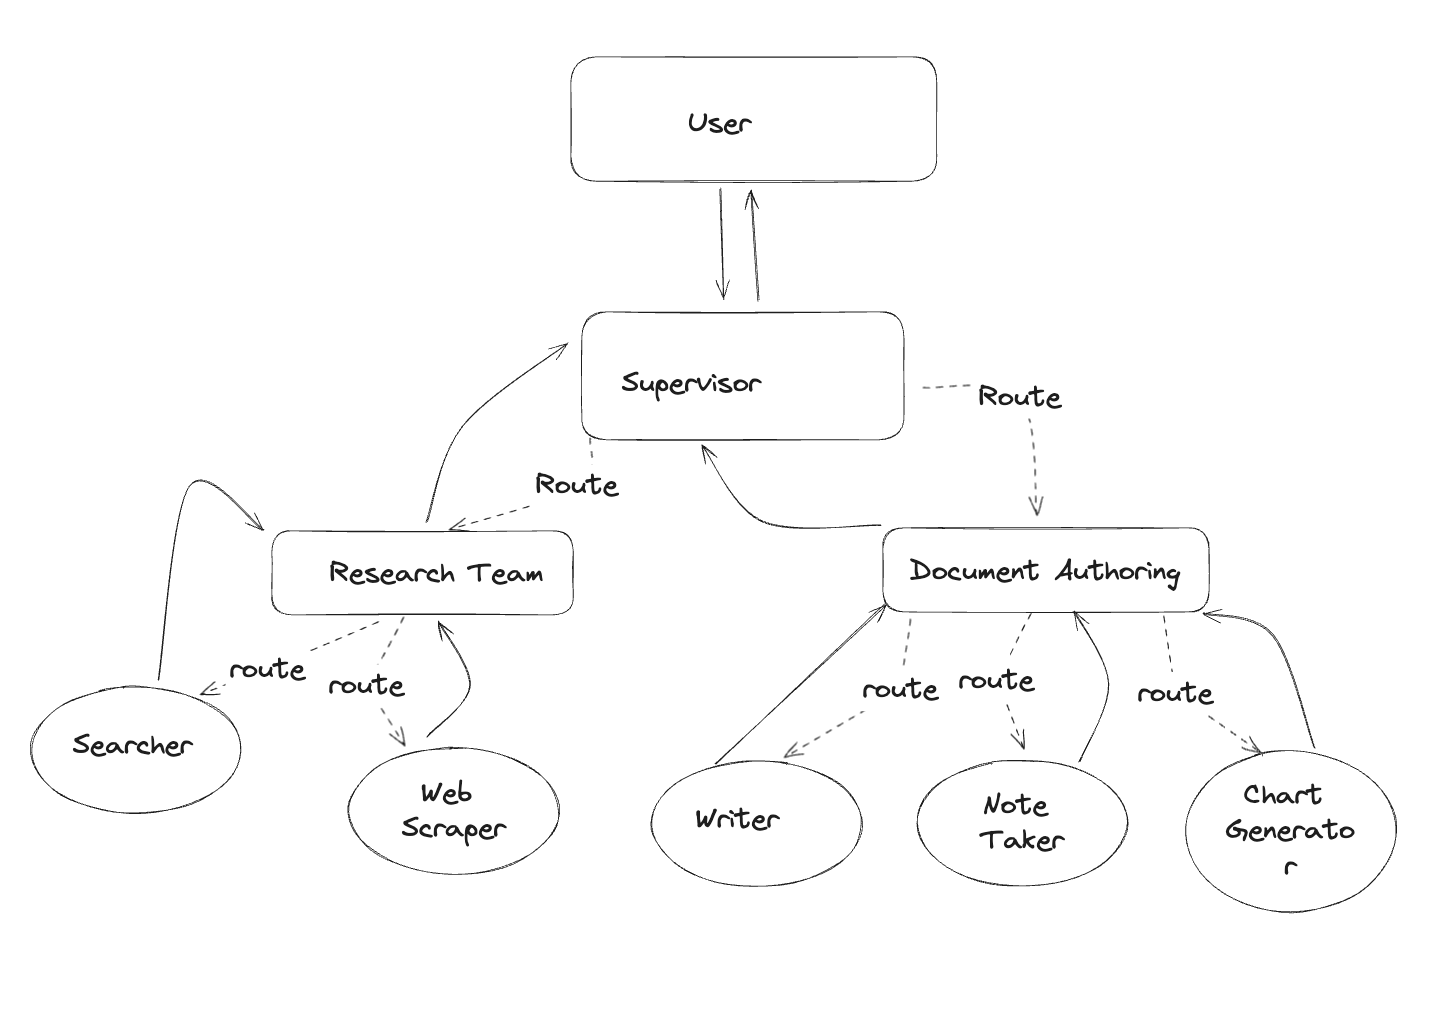


## 먼저 보는 구성 요소 지도

공통 State와 adapter를 만든 뒤 ResearchTeam, AuthoringTeam과 Top Graph 순서로 조립한다. Worker는 Tool 사용을 판단하고, 결정적 Supervisor는 반복 횟수와 종료 순서를 제한한다.

```text
Top Graph
├─ ResearchTeam: Search → WebScraper → 성공 또는 제한 재검색
└─ AuthoringTeam: NoteTaker → DocWriter → ChartGenerator
```

## 패키지 설치

LangChain Agent, OpenAI Chat Model, LangGraph, Tavily 검색, HTML 처리와 차트 생성에 필요한 패키지 목록을 현재 kernel에 설치한다. 출력은 뒤 셀에서 import할 수 있는 실행 환경이며, 설치 셀 자체는 외부 API를 호출하지 않는다.

In [ ]:
%pip install -U langchain langchain-openai langgraph langchain-tavily requests beautifulsoup4 python-dotenv matplotlib


## 환경 변수와 모델 ID

`find_dotenv`와 `load_dotenv`는 현재 작업 디렉터리의 환경 설정을 입력으로 읽는다. 출력은 두 팀이 공유할 Chat Model ID이며 뒤의 `ChatOpenAI` 생성에 사용한다. LangSmith 추적은 선택 기능으로 두고 비밀값은 출력하지 않는다.

In [ ]:
import os
from dotenv import find_dotenv, load_dotenv

# 현재 작업 디렉터리에서 .env를 찾고 기존 운영체제 환경 변수는 덮어쓰지 않는다.
dotenv_path = find_dotenv(usecwd=True)
if dotenv_path:
    load_dotenv(dotenv_path, override=False)

# LangSmith 키가 있을 때만 선택적인 추적을 활성화한다.
if os.getenv("LANGSMITH_API_KEY"):
    os.environ.setdefault("LANGSMITH_TRACING", "true")
    os.environ.setdefault("LANGSMITH_PROJECT", f"langgraph-collaboration")

OPENAI_CHAT_MODEL = os.getenv("OPENAI_CHAT_MODEL", "gpt-5.6-luna")


## 팀 State와 Worker adapter

> 🧭 **현재 위치 1/5 — 공통 부품**
>
> 팀에서 재사용할 State, Worker adapter와 순서형 Supervisor를 준비한다.

`TypedDict`와 `add_messages`로 누적 messages와 다음 목적지 next를 갖는 Team State를 정의한다. Worker adapter는 messages를 Agent에 전달하고 마지막 결과를 이름이 있는 `HumanMessage`로 바꾸며, 공유 `ChatOpenAI` 객체는 뒤의 Worker들이 사용한다.

## 반복을 막는 순서형 Supervisor factory

Worker 이름 목록을 입력받아 아직 완료되지 않은 첫 Worker 또는 FINISH를 반환하는 Supervisor factory를 만든다. `attrgetter`로 누적 message의 이름을 읽고, 반환된 next는 Conditional Edge가 다음 Node를 고를 때 사용한다.

## 공통 부품이 한 번 도는 흐름

앞에서 만든 State·Supervisor·Worker adapter는 두 팀에서 같은 순서로 사용된다. Supervisor Node는 다음 목적지인 `next`를 갱신하고, Conditional Edge는 그 값을 읽어 Worker를 선택한다. Worker adapter는 결과를 `messages`에 누적한 뒤 다시 Supervisor로 돌아간다.

```mermaid
flowchart LR
    S0["TeamState · messages / next"] --> SUP["Supervisor Node"]
    SUP -->|"next update"| S1["TeamState.next 갱신"]
    S1 --> EDGE{"Conditional Edge"}
    EDGE --> WORKER["Worker Node · 역할별 adapter"]
    WORKER -->|"Agent 실행 후 messages update"| S2["TeamState.messages 누적"]
    S2 --> SUP
```

`next`는 실행 위치를 정하는 제어 값이고 `messages`는 Worker 결과를 전달하는 데이터이다. 이후 두 팀은 State와 adapter의 세부 데이터가 달라도 이 기본 loop 구조는 동일하다.

## ResearchTeam의 검색과 안전한 본문 추출 Tool

> 🧭 **현재 위치 2/5 — ResearchTeam**
>
> URL 후보를 찾고 공개 본문을 읽어 근거 message를 만든다.

`TavilySearch`는 URL 후보를 반환하고 `tool`로 감싼 본문 함수는 `requests`와 `BeautifulSoup`을 사용해 공개 본문만 정제한다. HTTP(S)와 host를 확인하고 localhost·사설 IP를 차단하며, redirect 자동 추적을 끄고 timeout과 본문 길이를 제한한다.

URL 검증, DNS, HTTP 상태와 빈 본문의 실패는 URL별 상태로 남긴다. 성공 Source가 없으면 다른 domain을 찾도록 제어 상태를 반환하되 차단된 주소를 우회하지 않는다.

## ResearchTeam Worker와 역할 경계

`create_agent`로 Search Worker에는 검색 권한만, WebScraper Worker에는 공개 본문 Tool만 연결한다. 생성한 Agent는 `partial`로 공통 adapter에 묶어 Search Node로 바꾸고, WebScraper는 다음 단계의 전용 adapter가 감싼다.

## Tool 결과에서 WebScraper 완료 신호 만들기

WebScraper Agent 결과에서 `ToolMessage`만 모아 첫 줄 제어 상태와 본문을 분리한다. 성공 또는 다른 domain 검색 상태를 이름이 있는 `HumanMessage`로 바꾸면 Research Supervisor가 다음 경로를 선택할 수 있다.

## 검색·본문 추출·종료를 결정적 경로로 연결하기

정상 경로는 Search, WebScraper, FINISH 순서이다. 모든 URL이 실패한 경우에만 다른 domain 검색을 최대 두 번 허용하고, 그래도 Source가 없으면 NO_USABLE_SOURCE를 남기고 종료한다.

최신 Worker 이름, 첫 줄 상태와 누적 실패 횟수를 입력으로 읽어 다음 목적지를 반환하는 순수 Supervisor를 작성한다.

## ResearchTeam Subgraph 조립

ResearchTeam은 `START → Supervisor → Worker → Supervisor`를 사용하지만 다음 목적지는 자유로운 LLM 선택이 아니다. Supervisor는 최신 Worker 이름과 완료 신호를 읽어 정상 순서 또는 제한된 재검색만 허용한다.

`StateGraph`에 세 Node를 등록하고 `add_edge`로 Worker의 복귀 경로를 만든다. `add_conditional_edges`는 next 값을 Worker 또는 END에 연결하며, `compile` 결과는 뒤의 Top adapter가 실행할 ResearchTeam Subgraph가 된다.

### 성공·재검색·종료 경로

아래 흐름도에서 WebScraper의 status가 성공이면 FINISH로 이동한다. 모든 URL이 실패한 경우에만 Search로 돌아가며, 제한 횟수를 모두 사용하면 `NO_USABLE_SOURCE` message를 남기고 종료한다.

```mermaid
flowchart TD
    START((START)) --> SUP["Research Supervisor"]
    SUP -->|"첫 요청"| SEARCH["Search Node"]
    SEARCH -->|"URL 후보 message"| SUP
    SUP -->|"Search 완료"| SCRAPE["WebScraper Node"]
    SCRAPE -->|"status가 있는 message"| SUP
    SUP -->|"SOURCE_READY"| FINISH["FINISH route"]
    SUP -->|"SEARCH_OTHER_DOMAIN · 재검색 가능"| SEARCH
    SUP -->|"재검색 소진"| NOSOURCE["NO_USABLE_SOURCE message"]
    NOSOURCE --> FINISH
    FINISH --> END((END))
```

`recursion_limit`은 잘못된 반복을 끊는 안전 상한이지 완료 조건이 아니다. 흐름도의 실제 종료는 `research_supervisor()`가 반환하는 `FINISH`와 Conditional Edge가 담당한다.

## ResearchTeam의 정상 순서와 제한 재검색 확인

외부 호출 없이 최소 State를 만들어 최초 Search, Search 뒤 WebScraper와 성공 뒤 FINISH 순서를 확인한다. 이 확인값은 Graph 조립 전에 route 규칙이 올바른지 판단하는 근거가 된다.

## ResearchTeam의 제한 재검색 확인

실패 상태가 누적된 예시 message로 재검색과 종료 경계를 확인한다. 허용된 대체 검색을 모두 사용하면 NO_USABLE_SOURCE가 추가되고 FINISH가 선택되어야 한다.

## AuthoringTeam의 임시 작업 폴더

> 🧭 **현재 위치 3/5 — AuthoringTeam**
>
> 근거 message를 개요·보고서·제한된 차트 파일로 바꾸는 단계를 준비한다.

`TemporaryDirectory`와 `Path`로 실행 중인 작업 root를 준비한다. 이후 모든 파일 Tool은 이 root를 기준으로 상대 경로를 해석하며, 폴더 밖의 경로는 허용하지 않는다.

## 경로와 줄 범위를 제한한 문서 Tool

`Path.resolve`와 부모 경계 검사로 정규화한 대상이 작업 root 안에 있는지 확인해 path traversal을 차단한다. `tool`로 제공할 개요 생성, 문서 읽기·쓰기·편집 함수는 이 안전 경로만 사용하며 선택 줄 범위와 삽입 줄 번호도 검사한다.

## 임의 코드 실행 없이 차트를 만드는 Tool

label과 숫자 목록만 받아 `matplotlib` 막대 차트를 만드는 제한형 Tool을 작성한다. 두 목록의 길이와 PNG 확장자를 검사하고 작업 root 안에 저장해 임의 Python 실행 권한을 주지 않는다.

## AuthoringTeam State와 파일 context adapter

`TypedDict`와 `NotRequired`로 messages, next와 선택적 파일 목록을 갖는 Authoring State를 정의한다. adapter는 작업 root와 현재 파일명을 `SystemMessage`로 Worker에 전달하고 마지막 결과와 다시 계산한 파일 목록을 부분 State로 반환한다.

## AuthoringState와 작업 파일이 함께 갱신되는 흐름

`messages`에는 Worker의 대화 결과가 쌓이고, `current_files`에는 임시 작업 폴더의 상대 파일 목록만 들어간다. 실제 파일 내용은 State에 복사하지 않고 허용된 문서·차트 Tool이 필요할 때 읽거나 쓴다.

```mermaid
flowchart LR
    STATE["AuthoringState · messages / current_files"] --> NODE["run_authoring_node()"]
    NODE --> PROMPT["SystemMessage · 작업 root / 파일 목록"]
    PROMPT --> WORKER["선택된 Authoring Worker"]
    WORKER --> RESULT["마지막 Worker message"]
    WORKER -->|"필요할 때"| TOOL["허용된 문서 / 차트 Tool"]
    TOOL --> ROOT["임시 작업 폴더 · outline.md / report.md / PNG"]
    RESULT --> FILES["current_file_context() 재계산"]
    ROOT --> FILES
    RESULT --> UPDATE["부분 State return"]
    FILES --> UPDATE
    UPDATE -->|"messages + current_files update"| STATE
```

이 경계 덕분에 다음 Worker는 앞 단계가 만든 파일명을 알 수 있지만, 작업 폴더 밖의 경로나 허용되지 않은 실행 권한은 얻지 않는다.

## AuthoringTeam Worker와 고정된 작성 순서

`create_agent`로 NoteTaker에는 개요·읽기, DocWriter에는 읽기·쓰기·편집, ChartGenerator에는 읽기·제한 차트 권한만 준다. `partial`로 세 Agent를 같은 adapter 형식의 Node로 바꾸고 순서형 Supervisor에는 Worker 이름 순서를 전달한다.

## AuthoringTeam Subgraph 조립

AuthoringTeam도 Worker 실행 뒤 Supervisor로 돌아오지만, Supervisor는 완료된 `message.name`을 읽어 아직 실행하지 않은 다음 Worker만 선택한다. 따라서 각 Worker는 최대 한 번 실행되고 세 Worker가 끝나면 FINISH로 연결된다.

`StateGraph`에 Supervisor와 세 Worker를 등록하고 `add_edge`와 `add_conditional_edges`로 고정 복귀와 next 분기를 연결한다. `compile` 결과는 Top adapter가 호출할 AuthoringTeam Subgraph가 된다.

```mermaid
flowchart LR
    START((START)) --> SUP["Authoring Supervisor"]
    SUP -->|"1번째"| NOTE["NoteTaker"]
    NOTE --> SUP
    SUP -->|"2번째"| DOC["DocWriter"]
    DOC --> SUP
    SUP -->|"3번째"| CHART["ChartGenerator"]
    CHART --> SUP
    SUP -->|"모두 완료"| FINISH["FINISH route"]
    FINISH --> END((END))
    NOTE -.-> OUTLINE["outline.md"]
    DOC -.-> REPORT["report.md"]
    CHART -.-> PNG["PNG · 수치가 있을 때"]
```

실선은 Supervisor가 관리하는 실행 순서이고 점선은 각 Worker가 만드는 대표 산출물이다. 파일 목록은 `AuthoringState.current_files`로 공유하고, Tool 권한은 Worker별 목록으로 계속 제한한다.

## AuthoringTeam의 작성 순서와 안전한 보고서 경로 확인

외부 호출 없이 완료된 Worker 이름을 차례로 추가해 NoteTaker, DocWriter, ChartGenerator와 FINISH 순서를 확인한다. 보고서 상대 경로가 작업 root 안으로 해석되는지도 함께 점검한다.

## 팀 Subgraph를 상위 Node로 바꾸는 adapter

> 🧭 **현재 위치 4/5 — Top Graph**
>
> 완성된 두 팀을 Top Graph가 호출할 하나의 Node 형식으로 바꾼다.

`TopState`를 정의하고 팀 adapter가 상위 messages를 선택된 Subgraph의 `invoke` 입력으로 전달하게 한다. 마지막 팀 결과만 팀 이름이 있는 message로 바꾸며, `partial`은 두 Subgraph를 같은 Top Node 형식으로 고정하고 recursion limit은 안전 상한으로만 사용한다.

## 팀 내부 State가 TopState message로 바뀌는 경계

Top Graph는 팀 내부의 `TeamState`·`AuthoringState`와 Worker loop를 직접 읽지 않는다. `run_team_node()`가 팀 Subgraph를 끝까지 실행한 뒤 마지막 결과 하나만 팀 이름이 있는 `HumanMessage`로 바꿔 공개한다.

```mermaid
flowchart LR
    TOPIN["TopState.messages"] --> ADAPTER["run_team_node()"]
    ADAPTER -->|"team_graph.invoke()"| SUB["ResearchTeam 또는 AuthoringTeam Subgraph"]
    SUB -->|"팀 내부 loop"| LAST["마지막 팀 message"]
    LAST --> WRAP["HumanMessage · 팀 이름"]
    WRAP -->|"messages update"| TOPOUT["TopState.messages"]
```

`recursion_limit=16`은 adapter가 Subgraph를 호출할 때 사용하는 안전 상한이다. 상위 State로 전달되는 값은 제한 숫자가 아니라 팀의 마지막 공개 message이다.

## ResearchTeam 다음에는 AuthoringTeam을 한 번만 실행하기

정상 순서는 ResearchTeam, AuthoringTeam, FINISH이다. ResearchTeam의 첫 줄 상태가 NO_USABLE_SOURCE이면 작성 근거가 없으므로 AuthoringTeam을 건너뛰고 종료한다.

완료된 팀 이름과 최신 결과 상태를 읽어 다음 팀 또는 FINISH를 반환하는 Top Supervisor를 작성한다.

## Top-level Supervisor graph 조립

Top Supervisor는 `ResearchTeam → AuthoringTeam → FINISH` 순서를 관리한다. 각 팀이 끝나면 Top Supervisor로 돌아오지만, 완료된 팀 이름이 State에 남으므로 같은 팀을 다시 선택하지 않는다.

### 정상 경로와 근거 없음 종료

ResearchTeam의 마지막 공개 message가 `NO_USABLE_SOURCE`이면 AuthoringTeam을 건너뛴다. 그 외에는 AuthoringTeam을 한 번 실행하고 전체 Graph를 종료한다.

`StateGraph`에는 Top Supervisor와 두 팀 adapter를 Node로 등록한다. `add_edge`는 각 팀 결과를 Supervisor로 돌려보내고, `add_conditional_edges`는 next를 팀 Node 또는 END로 연결하며, `compile` 결과가 마지막 실행 셀의 진입점이 된다.

```mermaid
flowchart TD
    START((START)) --> TOP["TopSupervisor"]
    TOP -->|"첫 팀"| RESEARCH["ResearchTeam Node"]
    RESEARCH -->|"팀 결과 message"| TOP
    TOP -->|"NO_USABLE_SOURCE"| END((END))
    TOP -->|"Source 준비"| AUTHOR["AuthoringTeam Node"]
    AUTHOR -->|"팀 결과 message"| TOP
    TOP -->|"FINISH"| END
```

이 그림의 Team Node 하나는 내부 Worker 여러 개를 포함한 Subgraph이다. Top Graph에는 팀 내부 Worker 이름이 노출되지 않는다.

## Top Graph의 정상 순서와 근거 없음 차단 확인

최소 Top State로 최초 ResearchTeam, 성공 뒤 AuthoringTeam과 두 팀 완료 뒤 FINISH를 확인한다. 별도의 근거 없음 State도 FINISH로 연결되어 같은 팀 재실행과 근거 없는 작성을 막아야 한다.

## 공개 근거가 없을 때 AuthoringTeam 차단 확인

ResearchTeam 이름과 정확한 첫 줄 NO_USABLE_SOURCE를 가진 message를 입력해 Top Supervisor의 종료 선택을 확인한다. 본문 안의 우연한 문자열은 제어 상태로 사용하지 않는다.

## 조사부터 report.md 작성까지 한 번에 실행

> 🧭 **현재 위치 5/5 — 전체 실행**
>
> 사용자 요청이 두 팀을 거쳐 파일 산출물과 FINISH로 이어지는지 확인한다.

최상위 State에 공개 근거 조사, 개요·보고서와 조건부 차트 생성을 요청하는 message를 넣는다. `stream`에서 Top Node의 실행 순서와 State update를 확인하고, 마지막에는 보고서 존재 여부와 작업 폴더의 실제 파일 목록을 대조한다.

이 단계는 모델·검색·웹 요청과 로컬 파일 쓰기를 수행하므로 필요한 환경 설정을 준비한 뒤 실행한다.